In [1]:
# Built-in
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, TimeDistributed, GlobalAveragePooling2D, LSTM, Dense, Dropout
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)


In [ ]:
# Define the path to the dataset
base_path = 'D:\MobileLSTM-HMM-KAN\dataset\\celeb'
categories = ['fake', 'real']

# Initialize a list to hold data
data = []

# Process each category
for category in categories:
    category_path = os.path.join(base_path, category)
    for filename in os.listdir(category_path):
        if filename.endswith('.jpg'):
            try:
                id_part, frame_part = filename.split('_frame_')
                id_ = id_part.split('_')[0]
                frame = frame_part.split('.')[0]
                data.append({
                    'filename': filename,
                    'path': os.path.join(category_path, filename),
                    'id': int(id_),
                    'frame': int(frame),
                    'label': category
                })
            except ValueError:
                continue

# Convert the data to a DataFrame
df = pd.DataFrame(data)

In [3]:
# Đảm bảo đã có df_cropped.csv chứa đường dẫn ảnh đã crop
df['label_id'] = df['label'].map({'fake': 0, 'real': 1})
df


,filename,path,id,frame,label,label_id
0,222_id32_0007_frame_0028.jpg,/Users/admin/AIEngineer/DeepFakeProject/Datase...,222,28,fake,0
1,522_id7_0003_frame_0027.jpg,/Users/admin/AIEngineer/DeepFakeProject/Datase...,522,27,fake,0
2,501_id60_0007_frame_0022.jpg,/Users/admin/AIEngineer/DeepFakeProject/Datase...,501,22,fake,0
3,487_id59_0008_frame_0023.jpg,/Users/admin/AIEngineer/DeepFakeProject/Datase...,487,23,fake,0
4,239_id34_0004_frame_0007.jpg,/Users/admin/AIEngineer/DeepFakeProject/Datase...,239,7,fake,0
...,...,...,...,...,...,...
32367,082_id1_0001_frame_0027.jpg,/Users/admin/AIEngineer/DeepFakeProject/Datase...,82,27,real,1
32368,186_id2_0001_frame_0007.jpg,/Users/admin/AIEngineer/DeepFakeProject/Datase...,186,7,real,1
32369,200_id30_0005_frame_0014.jpg,/Users/admin/AIEngineer/DeepFakeProject/Datase...,200,14,real,1
32370,460_id56_0007_frame_0012.jpg,/Users/admin/AIEngineer/DeepFakeProject/Datase...,460,12,real,1


In [4]:
df['video_key'] = df['id'].astype(str) + "_" + df['label']

from collections import defaultdict

video_dict = defaultdict(list)
labels = {}

for _, row in df.iterrows():
    key = row['video_key']
    video_dict[key].append(row['path'])
    labels[key] = row['label_id']


In [5]:
!pip install opencv-python

In [6]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, TimeDistributed, LSTM, Dropout, Dense, GlobalAveragePooling2D, BatchNormalization, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from hmmlearn.hmm import GaussianHMM
from tfkan.layers import Conv2DKAN, DenseKAN  # Import KAN layers
from scipy.stats import mode
from tensorflow.keras.applications import EfficientNetB0


# Giả định đã có
video_keys = list(video_dict.keys())
video_labels = [labels[k] for k in video_keys]

img_size = (224, 224)
batch_size = 32
epochs = 50
n_splits = 5
sequence_len = 10
results = []
all_histories = []

# Data generator
class VideoSequence(tf.keras.utils.Sequence):
    def __init__(self, video_keys, video_dict, labels, batch_size, img_size, sequence_len=10, augment=False):
        self.video_keys = video_keys
        self.video_dict = video_dict
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.sequence_len = sequence_len
        self.augment = augment
        self.datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=15 if augment else 0,
            zoom_range=0.1 if augment else 0,
            horizontal_flip=augment
        )

    def __len__(self):
        return int(np.ceil(len(self.video_keys) / self.batch_size))

    def __getitem__(self, idx):
        batch_keys = self.video_keys[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_X, batch_y = [], []

        for key in batch_keys:
            frames = self.video_dict[key][:self.sequence_len]
            imgs = []
            for path in frames:
                img = cv2.imread(path)
                img = cv2.resize(img, self.img_size)
                img = self.datagen.random_transform(img) if self.augment else img
                img = img.astype('float32') / 255.0
                imgs.append(img)
            while len(imgs) < self.sequence_len:
                imgs.append(np.zeros((*self.img_size, 3), dtype='float32'))
            batch_X.append(imgs)
            batch_y.append(self.labels[key])

        return np.array(batch_X), np.array(batch_y)

# Build model cải tiến
def build_model(sequence_len, img_size):
    base_cnn = MobileNetV2(input_shape=(*img_size, 3), include_top=False, weights='imagenet')

    # Freeze toàn bộ backbone để giảm overfit
    base_cnn.trainable = False

    # CNN feature extractor
    cnn_out = GlobalAveragePooling2D()(base_cnn.output)
    cnn_model = Model(inputs=base_cnn.input, outputs=cnn_out)

    # Sequence input
    input_seq = Input(shape=(sequence_len, *img_size, 3))
    x = TimeDistributed(cnn_model)(input_seq)

    # Temporal modeling
    x = LSTM(64, return_sequences=False)(x)
    x = Dropout(0.5)(x)

    # Classification
    x = DenseKAN(1)(x)
    output = tf.keras.activations.sigmoid(x)

    model = Model(inputs=input_seq, outputs=output)
    return model

# HMM cải tiến
def hmm_postprocess(pred_probs, y_true, n_states=2):
    pred_probs = pred_probs.reshape(-1, 1)
    hmm = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=100)
    hmm.fit(pred_probs)
    hidden_states = hmm.predict(pred_probs)

    mapping = {}
    for state in np.unique(hidden_states):
        indices = [i for i in range(len(hidden_states)) if hidden_states[i] == state]
        state_labels = [y_true[i] for i in indices]
        if len(state_labels) > 0:
            mapped_label = mode(state_labels, keepdims=True).mode[0]
        else:
            mapped_label = 0  # fallbac
            # k
        mapping[state] = mapped_label

    hmm_labels = np.array([mapping[s] for s in hidden_states])
    return hmm_labels

# Training K-Fold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (trainval_idx, test_idx) in enumerate(skf.split(video_keys, video_labels), 1):
    print(f"\n===== Fold {fold} =====")

    trainval_keys = [video_keys[i] for i in trainval_idx]
    test_keys = [video_keys[i] for i in test_idx]

    y_trainval = [labels[k] for k in trainval_keys]
    train_keys, val_keys = train_test_split(trainval_keys, test_size=0.1, stratify=y_trainval, random_state=fold)

    train_gen = VideoSequence(train_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=True)
    val_gen = VideoSequence(val_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=False)
    test_gen = VideoSequence(test_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=False)

    model = build_model(sequence_len, img_size)
    model.compile(optimizer=Adamax(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

    model_path = f"best_model_fold{fold}.h5"
    checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    earlystop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs,
                        callbacks=[checkpoint, earlystop, reduce_lr], verbose=1)
    all_histories.append(history.history)

    model.load_weights(model_path)

    y_true = [labels[k] for k in test_keys]
    y_pred_prob = model.predict(test_gen).ravel()
    y_hmm_pred = hmm_postprocess(y_pred_prob, y_true)

    results.append({
        'fold': fold,
        'accuracy': accuracy_score(y_true, y_hmm_pred),
        'precision': precision_score(y_true, y_hmm_pred),
        'recall': recall_score(y_true, y_hmm_pred),
        'f1': f1_score(y_true, y_hmm_pred),
        'auc': roc_auc_score(y_true, y_pred_prob)
    })

print("\n📊 Tổng kết kết quả các fold:")
for r in results:
    print(f"Fold {r['fold']}: Accuracy={r['accuracy']:.4f}, F1={r['f1']:.4f}, AUC={r['auc']:.4f}")



===== Fold 1 =====


2025-08-13 16:44:55.179284: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-08-13 16:44:55.179311: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-08-13 16:44:55.179318: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-08-13 16:44:55.179340: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-13 16:44:55.179488: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2025-08-13 16:44:58.527165: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


25/25 [==============================] - ETA: 0s - loss: 0.7080 - accuracy: 0.5115  
Epoch 1: val_accuracy improved from -inf to 0.54023, saving model to best_model_fold1.h5


...

/opt/anaconda3/envs/environment_tf_216/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


25/25 [==============================] - 49s 2s/step - loss: 0.6929 - accuracy: 0.5500 - val_loss: 0.6861 - val_accuracy: 0.5057 - lr: 1.0000e-04
Epoch 2/50
25/25 [==============================] - ETA: 0s - loss: 0.6727 - accuracy: 0.5923  
Epoch 2: val_accuracy improved from 0.50575 to 0.55172, saving model to best_model_fold4.h5
25/25 [==============================] - 45s 2s/step - loss: 0.6727 - accuracy: 0.5923 - val_loss: 0.6806 - val_accuracy: 0.5517 - lr: 1.0000e-04
Epoch 3/50
25/25 [==============================] - ETA: 0s - loss: 0.6675 - accuracy: 0.5782 
Epoch 3: val_accuracy improved from 0.55172 to 0.57471, saving model to best_model_fold4.h5
25/25 [==============================] - 29s 1s/step - loss: 0.6675 - accuracy: 0.5782 - val_loss: 0.6751 - val_accuracy: 0.5747 - lr: 1.0000e-04
Epoch 4/50
25/25 [==============================] - ETA: 0s - loss: 0.6538 - accuracy: 0.6205 
Epoch 4: val_accuracy improved from 0.57471 to 0.58621, saving model to best_model_fold4.h5


Epoch 1/50
25/25 [==============================] - ETA: 0s - loss: 0.6960 - accuracy: 0.5109  
Epoch 1: val_accuracy improved from -inf to 0.57471, saving model to best_model_fold5.h5


/opt/anaconda3/envs/environment_tf_216/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


25/25 [==============================] - 30s 1s/step - loss: 0.6960 - accuracy: 0.5109 - val_loss: 0.6869 - val_accuracy: 0.5747 - lr: 1.0000e-04
Epoch 2/50
25/25 [==============================] - ETA: 0s - loss: 0.6830 - accuracy: 0.5391 
Epoch 2: val_accuracy did not improve from 0.57471
25/25 [==============================] - 27s 1s/step - loss: 0.6830 - accuracy: 0.5391 - val_loss: 0.6837 - val_accuracy: 0.5517 - lr: 1.0000e-04
Epoch 3/50
25/25 [==============================] - ETA: 0s - loss: 0.6730 - accuracy: 0.5685 
Epoch 3: val_accuracy did not improve from 0.57471
25/25 [==============================] - 28s 1s/step - loss: 0.6730 - accuracy: 0.5685 - val_loss: 0.6807 - val_accuracy: 0.5632 - lr: 1.0000e-04
Epoch 4/50
25/25 [==============================] - ETA: 0s - loss: 0.6667 - accuracy: 0.5826 
Epoch 4: val_accuracy improved from 0.57471 to 0.58621, saving model to best_model_fold5.h5
25/25 [==============================] - 27s 1s/step - loss: 0.6667 - accuracy: 0.5

In [7]:
results_df = pd.DataFrame(results)
print("📊 Kết quả trung bình:")
print(results_df.mean(numeric_only=True))
results_df


📊 Kết quả trung bình:
fold         3.000000
accuracy     0.886632
precision    0.895203
recall       0.860279
f1           0.873828
auc          0.666700
dtype: float64


,fold,accuracy,precision,recall,f1,auc
0,1,0.981567,0.964286,1.000000,0.981818,0.683656
1,2,0.926267,1.000000,0.851852,0.920000,0.619266
2,3,0.953917,0.915966,1.000000,0.956140,0.639823
3,4,0.576037,0.604938,0.449541,0.515789,0.668620
4,5,0.995370,0.990826,1.000000,0.995392,0.722136


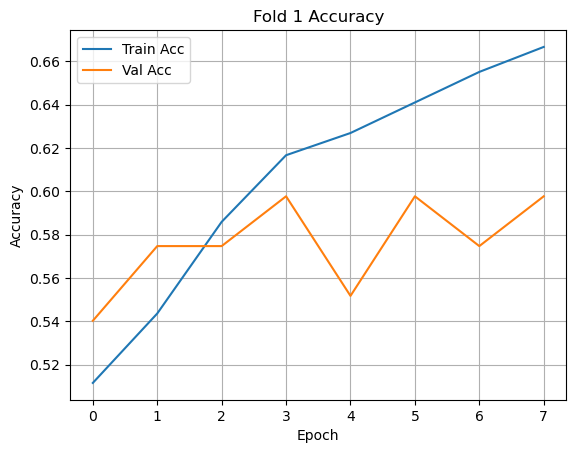

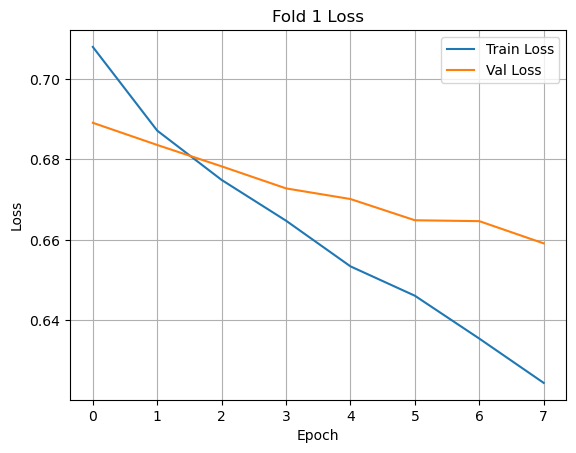

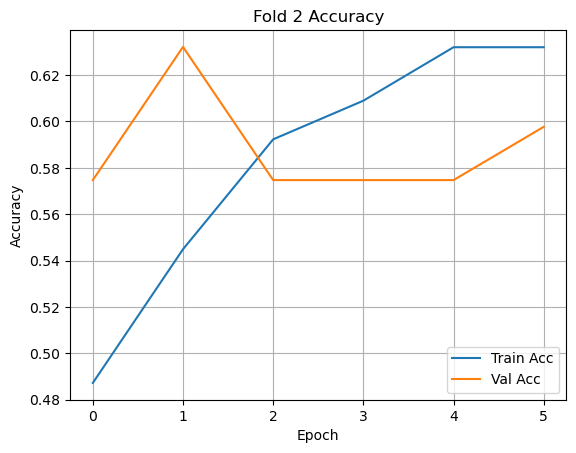

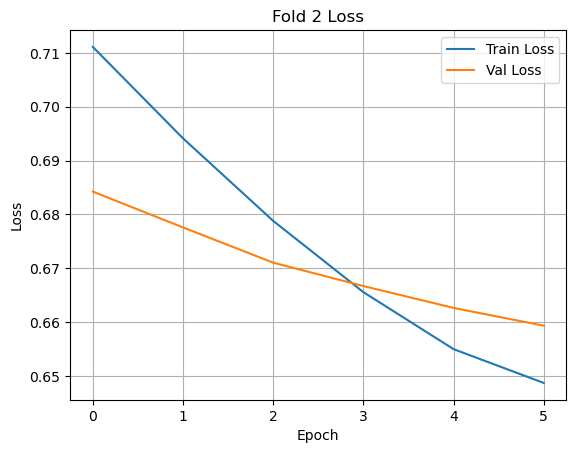

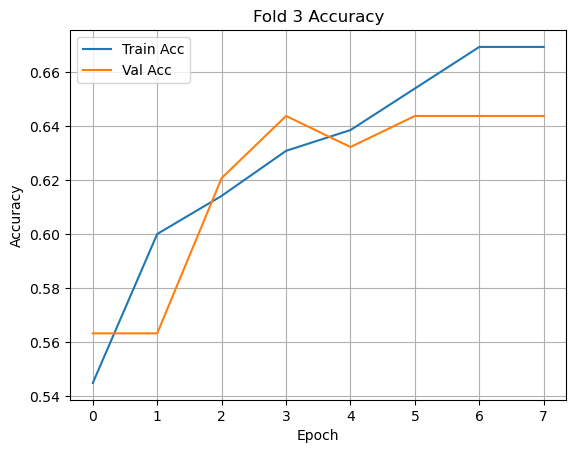

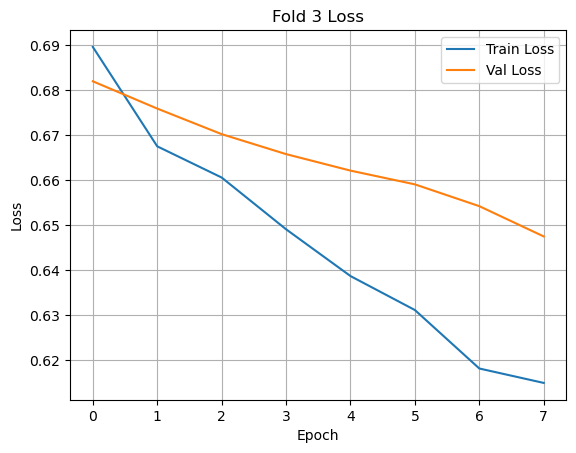

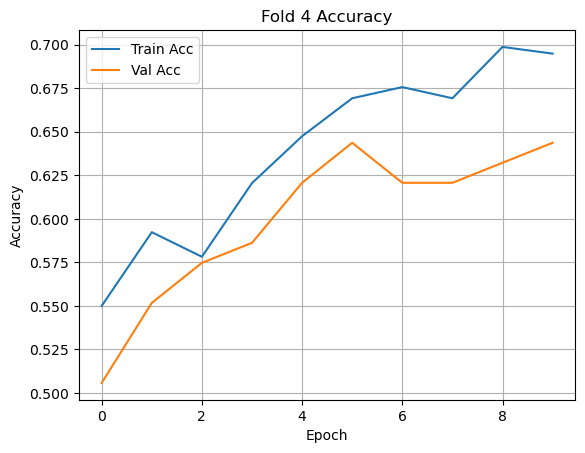

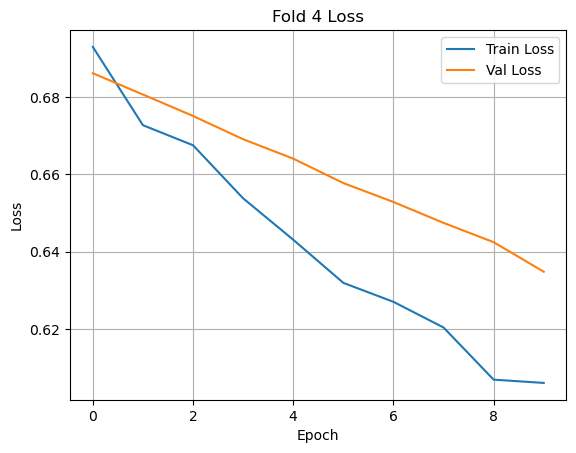

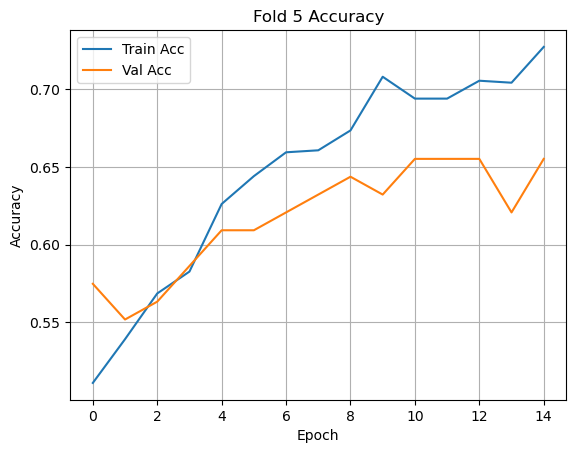

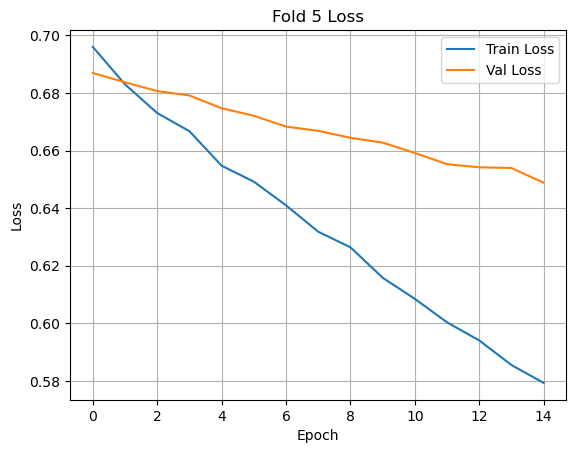

In [8]:
for i, hist in enumerate(all_histories, 1):
    plt.figure()
    plt.plot(hist['accuracy'], label='Train Acc')
    plt.plot(hist['val_accuracy'], label='Val Acc')
    plt.title(f'Fold {i} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title(f'Fold {i} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


In [9]:
# Save mô hình fold cuối cùng
model.save("mobilenetv2_hmm_faceplus_final.h5")


/opt/anaconda3/envs/environment_tf_216/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
results_df = pd.DataFrame(results)
print("📊 Kết quả trung bình:")
print(results_df.mean(numeric_only=True))
results_df


📊 Kết quả trung bình:
fold         3.000000
accuracy     0.886632
precision    0.895203
recall       0.860279
f1           0.873828
auc          0.666700
dtype: float64


,fold,accuracy,precision,recall,f1,auc
0,1,0.981567,0.964286,1.000000,0.981818,0.683656
1,2,0.926267,1.000000,0.851852,0.920000,0.619266
2,3,0.953917,0.915966,1.000000,0.956140,0.639823
3,4,0.576037,0.604938,0.449541,0.515789,0.668620
4,5,0.995370,0.990826,1.000000,0.995392,0.722136


In [11]:
import pandas as pd

# Giả sử results đã có và bạn đã tạo results_df
results_df = pd.DataFrame(results)

# Tính các chỉ số
accuracy_mean = results_df['accuracy'].mean()
accuracy_std = results_df['accuracy'].std()  # dùng sample std (chia cho n-1)
accuracy_range = results_df['accuracy'].max() - results_df['accuracy'].min()
accuracy_cv_percent = (accuracy_std / accuracy_mean) * 100

# In kết quả
print("📊 Kết quả trung bình:")
print(results_df.mean(numeric_only=True))

print(f"\n✅ CV Accuracy (Mean Accuracy): {accuracy_mean:.4f}")
print(f"📈 Range Accuracy: {accuracy_range:.4f}")
print(f"📉 Accuracy CV% (std/mean): {accuracy_cv_percent:.2f}%")

# Hiển thị bảng kết quả nếu cần
results_df


📊 Kết quả trung bình:
fold         3.000000
accuracy     0.886632
precision    0.895203
recall       0.860279
f1           0.873828
auc          0.666700
dtype: float64

✅ CV Accuracy (Mean Accuracy): 0.8866
📈 Range Accuracy: 0.4193
📉 Accuracy CV% (std/mean): 19.81%


,fold,accuracy,precision,recall,f1,auc
0,1,0.981567,0.964286,1.000000,0.981818,0.683656
1,2,0.926267,1.000000,0.851852,0.920000,0.619266
2,3,0.953917,0.915966,1.000000,0.956140,0.639823
3,4,0.576037,0.604938,0.449541,0.515789,0.668620
4,5,0.995370,0.990826,1.000000,0.995392,0.722136
